In [ ]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
base_path = Path("/content/drive/MyDrive/ml/") # change to path folder with data

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

## Obserwacje z poprzedniego zadania (EDA) i ich wykorzystanie w procesie tworzenia modelu

### Co było przydatne:

*   **Identyfikacja kluczowych cech predykcyjnych:** Analiza EDA wyraźnie wskazała, że takie cechy jak `Sex`, `Pclass`, `Age`, `Fare` oraz nowo utworzone `FamilySize`, `Title` i `Deck` mają silny związek z szansą przeżycia. Będą one stanowić podstawę dla modeli klasyfikacyjnych.
*   **Uzupełnianie brakujących danych:** Poznaliśmy strategie uzupełniania braków (`Age` medianą grupową, `Fare` medianą z `Pclass`, `Embarked` dominantą, `Deck` jako nową kategorią 'Unknown'), co pozwoliło nam zachować jak najwięcej danych i uniknąć ich utraty.
*   **Inżynieria cech:** Stworzenie nowych cech (`FamilySize`, `IsAlone`, `Title`, `Deck`, `HasCabin`) na podstawie istniejących okazało się bardzo wartościowe. Przykładowo, `Title` uchwyciło subtelne zależności związane ze statusem społecznym i wiekiem, a `FamilySize` pokazało, że zarówno zbyt mała, jak i zbyt duża rodzina negatywnie wpływała na szanse przeżycia.
*   **Wizualizacja rozkładów:** Rozkłady zmiennych względem `Survived` pomogły zrozumieć, które kategorie i zakresy wartości mają większe szanse na przeżycie. To wiedza, którą możemy wykorzystać do interpretacji wyników modelu.
*   **Standaryzacja / Skalowanie:** Zauważyliśmy występowanie wartości odstających, szczególnie w kolumnach `Fare`, `Age` i `FamilySize`. Modele wrażliwe na skalę (np. SVM, sieci neuronowe) będą wymagały standaryzacji tych cech, aby działały poprawnie i zbiegały się szybciej.
*   **Kodowanie zmiennych kategorycznych:** `One-hot encoding` dla zmiennych kategorycznych takich jak `Sex`, `Embarked`, `Title`, `Deck` jest niezbędny, ponieważ większość modeli uczenia maszynowego wymaga numerycznych danych wejściowych.

### Co okazało się bezużyteczne (i zostało usunięte lub przekształcone):

*   **`PassengerId`:** Numer identyfikacyjny pasażera nie ma żadnej wartości predykcyjnej i został usunięty.
*   **`Name`:** Sama nazwa była bezużyteczna, ale posłużyła do ekstrakcji wartościowej cechy `Title`, po czym została usunięta.
*   **`Ticket`:** Numer biletu okazał się losowy i nie miał żadnego widocznego wpływu na przeżycie, dlatego został usunięty.
*   **`Cabin`:** Pomimo dużej liczby braków, udało się z niej wydobyć informację o pokładzie (`Deck`) oraz o tym, czy pasażer miał przypisaną kabinę (`HasCabin`). Surowa kolumna `Cabin` została usunięta.
*   **`SibSp` i `Parch`:** Te kolumny, choć same w sobie mogą mieć pewną wartość, zostały połączone w `FamilySize`, co okazało się bardziej syntetyczną i użyteczną cechą, a oryginalne kolumny usunięte w celu uniknięcia redundancji i wielokrotnego liczenia.

### Wnioski do wykorzystania w procesie tworzenia modelu:

1.  **Feature selection:** Skupimy się na wcześniej zidentyfikowanych istotnych cechach.
2.  **Preprocessing:** Konieczna będzie standaryzacja cech numerycznych oraz odpowiednie kodowanie cech kategorycznych.
3.  **Obsługa outlierów:** Ze względu na obecność outlierów, należy rozważyć modele mniej wrażliwe na nie (np. drzewa decyzyjne) lub odpowiednie metody ich transformacji/obsługi.
4.  **Zbalansowanie klas:** Warto sprawdzić, czy klasy (`Survived` 0 i 1) są zbalansowane. Jeśli nie, trzeba będzie zastosować techniki balansowania, aby modele nie były stronnicze.

Te wnioski będą stanowić solidną podstawę do dalszego etapu budowy, trenowania i oceny modeli klasyfikacyjnych.

### Krótkie podsumowanie odpowiedzi:

1.  **Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?**
    Poprzednie zadanie pozwoliło zidentyfikować kluczowe cechy predykcyjne (płeć, klasa, wiek, itd.) oraz metody uzupełniania brakujących danych i inżynierii cech, które będą podstawą budowy modelu. Usunięto lub przekształcono cechy takie jak `PassengerId`, `Name` (po ekstrakcji tytułu), `Ticket`, `Cabin` (po ekstrakcji pokładu), `SibSp` i `Parch`, ponieważ były bezużyteczne lub redundantne.

2.  **Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?**
    Standaryzacja danych skaluje cechy do podobnego zakresu, zapobiegając dominacji cech o większych wartościach. Dzięki temu algorytmy oparte na odległości i spadku gradientu działają efektywniej i stabilniej, poprawiając zbieżność i wydajność modelu.

3.  **Co mój model robi i w jaki sposób?**
    Model będzie klasyfikatorem przewidującym, czy pasażer Titanica przeżył (1) czy nie (0), na podstawie dostarczonych cech. Uczy się on wzorców i zależności między cechami wejściowymi a wynikiem przeżycia, aby dokonywać nowych predykcji.

4.  **Jak nie przetrenować wybranego modelu?**
    Aby uniknąć przetrenowania, stosuje się podział danych na zbiory treningowy, walidacyjny i testowy oraz walidację krzyżową. Inne techniki to regularyzacja, wcześniejsze zatrzymywanie treningu, uproszczenie modelu oraz zwiększenie danych treningowych.

5.  **Jaki wynik klasyfikacji możemy uznać za dobry?**
    Dobry wynik klasyfikacji zależy od kontekstu problemu, ale ogólnie oznacza wysoką dokładność (dla zbalansowanych klas) i dobrą równowagę precyzji/czułości (F1-Score) lub wysoką wartość metryki kluczowej dla problemu. Ważne jest również wysokie AUC-ROC oraz spójne wyniki na zbiorach walidacyjnym i testowym.

In [ ]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

# Priorytet ewakuacji


In [ ]:
display(pd.crosstab(
    titanic_df['Survived'],
    titanic_df['Sex'],
    normalize='columns'
    ) * 100)


Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


# Odpowiedzi na pytania

1. **Czy wszystkie kolumny są istotne w kontekście zadania?**

# Podział kolumn pod kątem przydatności w modelu

## Kolumny przydatne (Zostają w modelu)

* **`Sex`** — Kobiety miały priorytet podczas ewakuacji (przeżyło ponad 70% kobiet vs ok. 20% mężczyzn).
* **`Pclass`** - Klasa podróży (1, 2, 3) decydowała o bliskości do pokładu z łodziami i statusie społecznym.
* **`Age`** — Dzieci miały większą szansę na ratunek (wymaga uzupełnienia braków).
* **`Fare`** — Informuje o zamożności i dokładnym usytuowaniu na statku.
* **`SibSp` & `Parch`** — Informują o liczbie rodzeństwa/małżonków i rodziców/dzieci. Pozwalają stworzyć cechę wielkości rodziny (`FamilySize`).
* **`Embarked`** — Port zaokrętowania (C, Q, S). Może wskazywać na zamożność pasażerów w danym mieście.

---

## Kolumny nieprzydatne (Do usunięcia)

* **`PassengerId`** — Zwykły numer wiersza. Nie ma żadnego wpływu na przeżycie.
* **`Ticket`** — Unikalny kod biletu (często ciąg przypadkowych liter i cyfr). Brak bezpośredniej wartości predykcyjnej.

---

## Kolumny "ukryte" (Warto z nich coś wyciągnąć, a potem usunąć)

* **`Name`** — Sama nazwa jest nieprzydatna, ale zawiera **tytuł** (np. *Mr*, *Mrs*, *Master*, *Miss*).
* **`Cabin`** — Ma 77% braków. Zamiast usuwać od razu, zrób zmienną `HasCabin` (1 jeśli miał kabinę, 0 jeśli brak) lub wyciągnij literę pokładu (`Deck`), a surową `Cabin` usuń.




2. **Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz?**

Tak w kolumnach: `Cabin, Age, Fare, Embarked`

,missing,missing_percentage (%)
Cabin,687,77.10
Age,177,19.87
Fare,98,11.00
Embarked,2,0.22


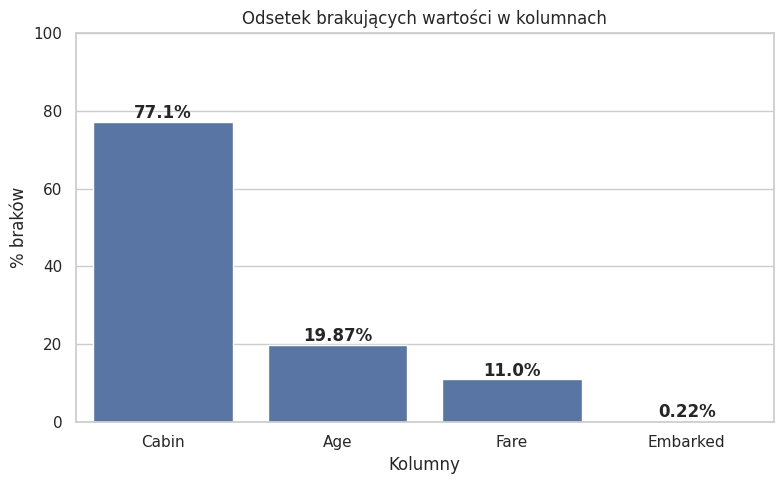

In [ ]:
missing_matrix = pd.DataFrame({
    'missing': titanic_df.isna().sum(),
    'missing_percentage (%)': (titanic_df.isna().sum() / len(titanic_df) * 100).round(2)
})

missing_data_filtered = missing_matrix[missing_matrix['missing'] > 0].sort_values(by='missing', ascending=False)

display(missing_matrix[missing_matrix['missing_percentage (%)'] > 0].sort_values(by='missing_percentage (%)', ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=missing_data_filtered.index,
    y=missing_data_filtered["missing_percentage (%)"],
    ax=ax,
    color="#4C72B0"
)

ax.set_ylabel("% braków")
ax.set_xlabel("Kolumny")
ax.set_title("Odsetek brakujących wartości w kolumnach")
ax.set_ylim(0, 100)
for i, v in enumerate(missing_data_filtered["missing_percentage (%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

3. **Czy typy danych są odpowiednie do znaczenia kolumny?**

Nie.

Pclass (Klasa podróży) -> Typ kategoryczny uporządkowany

Name --> str

Sex --> Label Encoding (0 lub 1)

Age --> int64

Ticket --> str

Embarked --> typ kategoryczne nieuporządkowane (category)

In [ ]:
display(Markdown('### Informacje na temat kolumn'))

display(Markdown('### Podstawowe statystyki'))
display(titanic_df.describe(include="all").T)

display(Markdown('### 5 pierwszych wierszy'))
display(titanic_df.head())

### Informacje na temat kolumn

### Podstawowe statystyki

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,793.0,NaN,NaN,NaN,33.123938,51.578312,0.0,7.925,14.5,31.275,512.3292
Cabin,204,147,G6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5 pierwszych wierszy

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Zmiana typów danych

In [ ]:
import pandas as pd

# Pclass -> Typ numeryczny (int64)
# Pclass jest już int64, ponowne przypisanie dla jasności.
titanic_df['Pclass'] = titanic_df['Pclass'].astype('int64')

# Name & Ticket -> Typ tekstowy (string)
titanic_df['Name'] = titanic_df['Name'].astype('string')
titanic_df['Ticket'] = titanic_df['Ticket'].astype('string')

# Sex -> (Zostawiamy jako 'male'/'female' dla wizualizacji, konwersja na numeryczne nastąpi później)

# Cabin oraz Embarked -> Typy kategoryczne nieuporządkowane
titanic_df['Cabin'] = titanic_df['Cabin'].astype('category')
titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')

display(Markdown("### 3. Weryfikacja końcowa struktury danych po zmianie typów"))
titanic_df.info()

### 3. Weryfikacja końcowa struktury danych po zmianie typów

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Name      891 non-null    string  
 3   Sex       891 non-null    object  
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    string  
 8   Fare      793 non-null    float64 
 9   Cabin     204 non-null    category
 10  Embarked  889 non-null    category
dtypes: category(2), float64(2), int64(4), object(1), string(2)
memory usage: 77.6+ KB


## Ekstracja nowych cech



In [ ]:
# Wyciągnięcie tytulu z nazwiska (Mr, Mrs, Miss, Master itp.)
titanic_df['Title'] = titanic_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Tworzenie zmiennych dotyczących rodziny (suma + pasażer)
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

# IsAlone: Flaga 1/0 – sprawdzamy czy rozmiar rodziny wynosi 1
titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

# Tworzenie zmiennych z kolumny Cabin
titanic_df['Deck'] = titanic_df['Cabin'].str[0].astype('category')
titanic_df['HasCabin'] = (titanic_df['Cabin'].notna()).astype(int)

# Weryfikacja
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Name        891 non-null    string  
 3   Sex         891 non-null    object  
 4   Age         714 non-null    float64 
 5   SibSp       891 non-null    int64   
 6   Parch       891 non-null    int64   
 7   Ticket      891 non-null    string  
 8   Fare        793 non-null    float64 
 9   Cabin       204 non-null    category
 10  Embarked    889 non-null    category
 11  Title       891 non-null    string  
 12  FamilySize  891 non-null    int64   
 13  IsAlone     891 non-null    int64   
 14  Deck        204 non-null    category
 15  HasCabin    891 non-null    int64   
dtypes: category(3), float64(2), int64(7), object(1), string(3)
memory usage: 106.6+ KB


## Uzupełnienie brakujących danych i usuniecie zbednych kolumn

In [ ]:
# 1. Uzupełnienie Age medianą z grupy Title + zabezpieczenie globalną medianą
# Weryfikujemy istnienie kolumny 'Title' przed próbą grupowania.
# Jeśli 'Title' brakuje, uzupełnimy 'Age' globalną medianą.
if 'Title' in titanic_df.columns:
    titanic_df['Age'] = titanic_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
else:
    print("Ostrzeżenie: Kolumna 'Title' nie jest dostępna do imputacji 'Age'. Uzupełniam 'Age' globalną medianą.")
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

# 2. Uzupełnienie Fare medianą z danej Pclass
if 'Fare' in titanic_df.columns:
    titanic_df['Fare'] = titanic_df.groupby('Pclass', observed=False)['Fare'].transform(lambda x: x.fillna(x.median()))
    titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())
else:
    print("Krytyczny błąd: Brak kolumny 'Fare'. Nie można przeprowadzić imputacji opartej na Pclass. Dodaję kolumnę 'Fare' wypełnioną wartością 0.0 jako placeholder.")
    titanic_df['Fare'] = 0.0 # Placeholder

# 3. Uzupełnienie Embarked dominantą (mode)
if 'Embarked' in titanic_df.columns:
    most_frequent_embarked = titanic_df['Embarked'].mode()[0]
    titanic_df['Embarked'] = titanic_df['Embarked'].fillna(most_frequent_embarked)
else:
    print("Krytyczny błąd: Brak kolumny 'Embarked'. Nie można przeprowadzić imputacji. Dodaję 'Unknown' jako placeholder.")
    titanic_df['Embarked'] = 'Unknown'
    titanic_df['Embarked'] = titanic_df['Embarked'].astype('category')

# 4. Obsługa braku Deck jako nowej kategorii 'Unknown'
# Kolumna 'Deck' powinna być stworzona wcześniej. Jeśli nie, tworzę ją jako 'Unknown'.
if 'Deck' not in titanic_df.columns:
    print("Ostrzeżenie: Brak kolumny 'Deck'. Tworzę ją jako 'Unknown'.")
    titanic_df['Deck'] = 'Unknown'
    titanic_df['Deck'] = titanic_df['Deck'].astype('category')
elif 'Unknown' not in titanic_df['Deck'].cat.categories:
    titanic_df['Deck'] = titanic_df['Deck'].cat.add_categories('Unknown')
titanic_df['Deck'] = titanic_df['Deck'].fillna('Unknown')

# Usunięcie surowych i zbędnych kolumn
cols_to_drop = ['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']

titanic_df = titanic_df.drop(columns=cols_to_drop, errors='ignore')

# Weryfikacja
titanic_df.info()

# Podgląd końcowy
titanic_df.head()

Critical Error: 'Embarked' column is missing. Cannot proceed with imputation. Adding a 'Unknown' placeholder to prevent crash.
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Survived        891 non-null    int64   
 1   Pclass          891 non-null    int64   
 2   Age             891 non-null    int64   
 3   Fare            891 non-null    float64 
 4   FamilySize      891 non-null    int64   
 5   IsAlone         891 non-null    int64   
 6   HasCabin        891 non-null    int64   
 7   Sex_male        891 non-null    int64   
 8   Embarked_Q      891 non-null    int64   
 9   Embarked_S      891 non-null    int64   
 10  Title_Col       891 non-null    int64   
 11  Title_Countess  891 non-null    int64   
 12  Title_Don       891 non-null    int64   
 13  Title_Dr        891 non-null    int64   
 14  Title_Jonkheer  891 non-null    

,Survived,Pclass,Age,Fare,FamilySize,IsAlone,HasCabin,Sex_male,Embarked_Q,Embarked_S,...,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Embarked,Deck
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,22,7.2500,2,0,0,1,0,1,...,0,0,0,0,0,0,0,1,Unknown,Unknown
2,1,1,38,71.2833,2,0,1,0,0,0,...,0,1,0,0,0,0,0,0,Unknown,Unknown
3,1,3,26,7.9250,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,Unknown,Unknown
4,1,1,35,53.1000,2,0,1,0,0,1,...,0,1,0,0,0,0,0,0,Unknown,Unknown
5,0,3,35,8.0500,1,1,0,1,0,1,...,0,0,0,0,0,0,0,1,Unknown,Unknown


4. **Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne?**


Kolumny numeryczne: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']


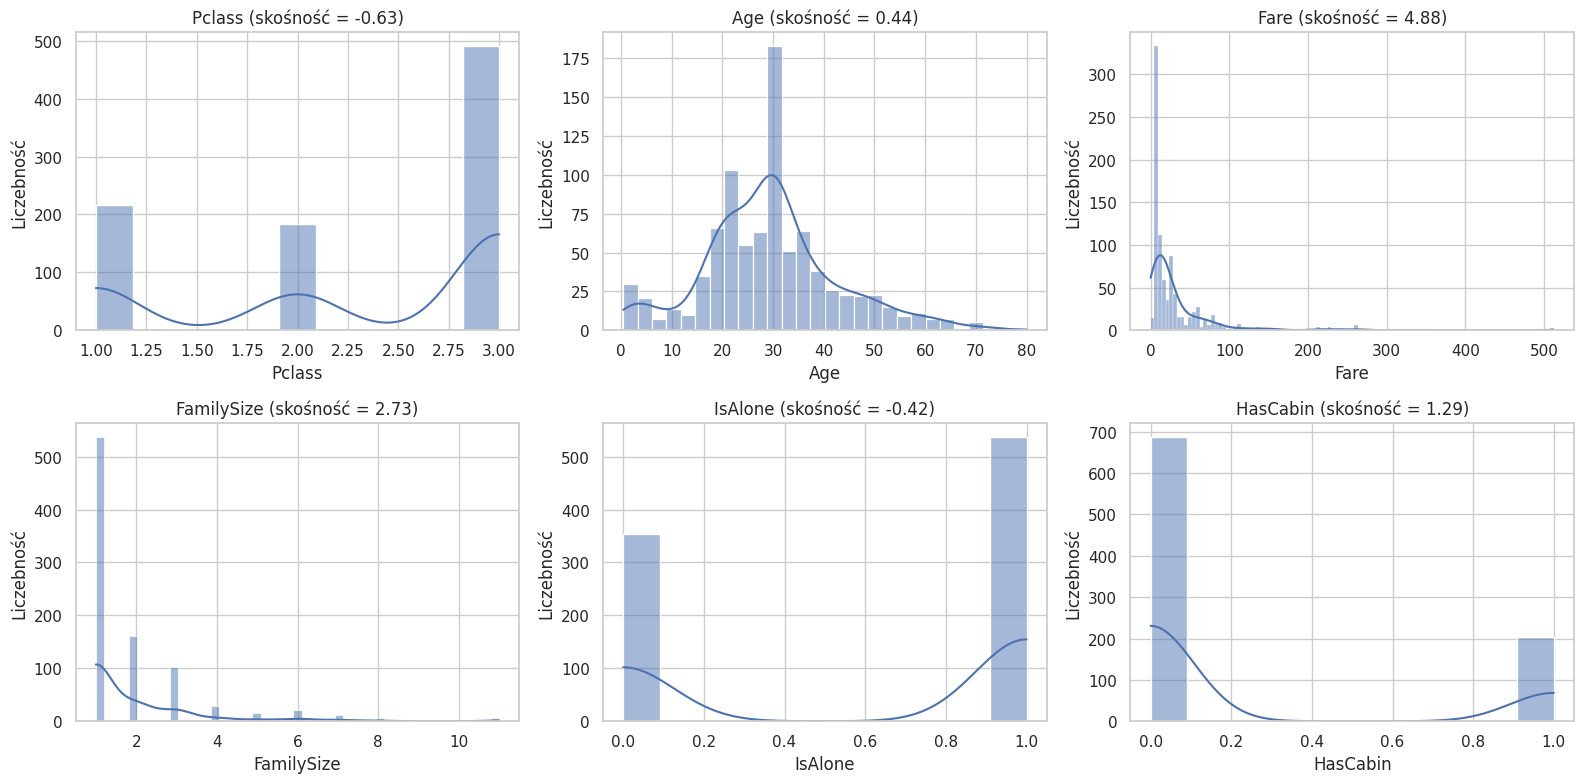

In [ ]:
numeric_cols = titanic_df.select_dtypes(exclude=['category', 'string', 'object']).columns.tolist()
# Usunięcie 'Survived' z kolumn numerycznych, ponieważ jest to zmienna binarna, ale nie jest ciągła
if 'Survived' in numeric_cols:
    numeric_cols.remove('Survived')

print(f'Kolumny numeryczne: {numeric_cols}')

# Ustawienie liczby kolumn do wyświetlenia w siatce (max 3)
num_plots = len(numeric_cols)
num_cols_grid = min(num_plots, 3)
num_rows_grid = (num_plots + num_cols_grid - 1) // num_cols_grid # Obliczenie liczby wierszy

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(16, num_rows_grid * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(titanic_df[col], kde=True, ax=axes[i], color="#4C72B0")
        skew = titanic_df[col].skew()
        axes[i].set_title(f"{col} (skośność = {skew:.2f})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Liczebność")

# Wyłączenie nieużywanych sub-wykresów, jeśli jest ich więcej niż kolumn do wizualizacji
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Najbradziej użyteczne do predykcji są:

```
Fare, Age, FamilySize
```



5. **Która zmienna oznacza predykowaną klasę?**

Zgodnie z treścią zadania:

```
Survived
```





6. **Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych jak i numerycznych?**


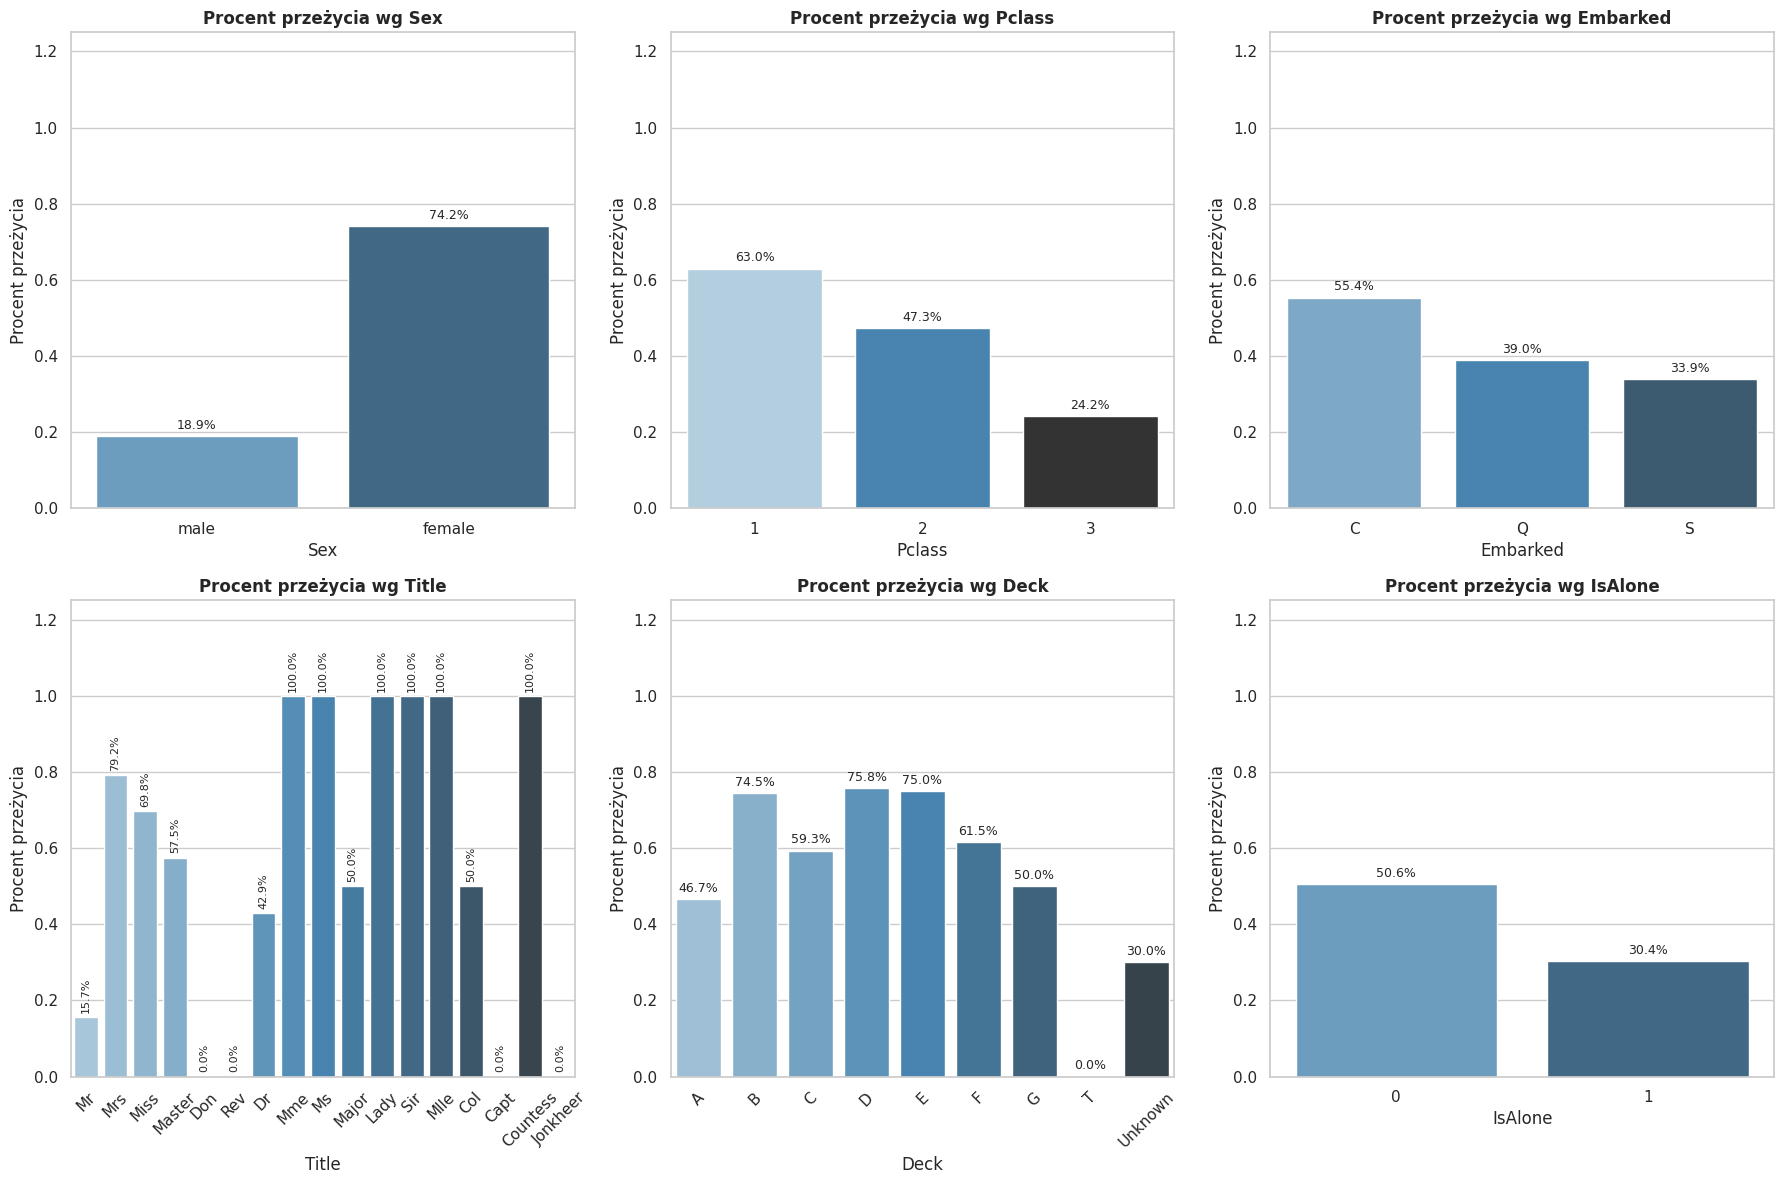

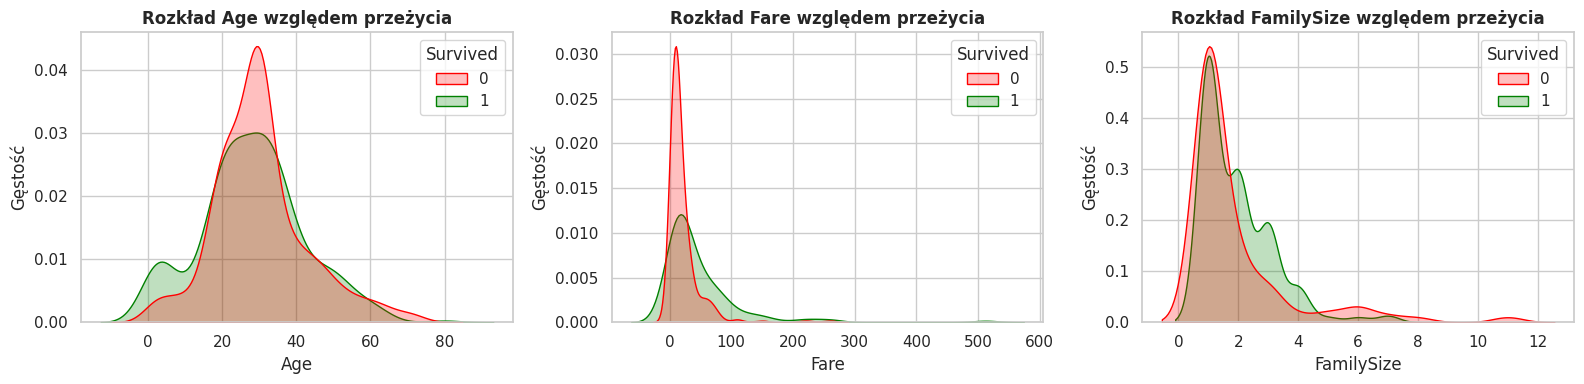

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cat_cols = ['Sex', 'Pclass', 'Embarked', 'Title', 'Deck', 'IsAlone']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.barplot(
        data=titanic_df,
        x=col,
        y='Survived',
        ax=ax,
        hue=col,
        palette='Blues_d',
        legend=False,
        errorbar=None
    )
    ax.set_title(f'Procent przeżycia wg {col}', fontsize=12, fontweight='bold') # Zmieniono tytuł
    ax.set_ylabel('Procent przeżycia')
    ax.set_xlabel(col)
    ax.set_ylim(0, 1.25)

    if col in ['Title', 'Deck']:
        ax.tick_params(axis='x', rotation=45)

    # nanoszenie etykiet
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height >= 0:
            # dla Title używamy obrotu etykiety o 90 stopni, aby uniknąć nachodzenia
            rotation_val = 90 if col == 'Title' else 0
            font_sz = 8 if col == 'Title' else 9

            ax.annotate(
                f"{height*100:.1f}%",
                (p.get_x() + p.get_width() / 2., height), # Dostosowanie pozycji etykiety
                ha='center',
                va='bottom',
                xytext=(0, 3),
                textcoords='offset points',
                fontsize=font_sz,
                rotation=rotation_val
            )

plt.tight_layout()
plt.show()

# zmienne numeryczne vs Survived
num_cols = ['Age', 'Fare', 'FamilySize']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(
        data=titanic_df,
        x=col,
        hue='Survived',
        ax=ax,
        common_norm=False,
        fill=True,
        palette={0: 'red', 1: 'green'}
    )
    ax.set_title(f'Rozkład {col} względem przeżycia', fontsize=12, fontweight='bold') # Zmieniono tytuł
    ax.set_xlabel(col)
    ax.set_ylabel('Gęstość') # Dodano etykietę osi y

plt.tight_layout()
plt.show()

7. **Czy końcowe rozkłady zawierają wartości skrajne?**

Tak, końcowe rozkłady zawierają wartości skrajne, szczególnie w przypadku cech Fare, Age oraz FamilySize. Najbardziej ekstremalne outliery występują w cenie biletu (Fare), gdzie pojedyncze luksusowe rezerwacje przekraczają 500 USD przy medianie wynoszącej kilkanaście dolarów

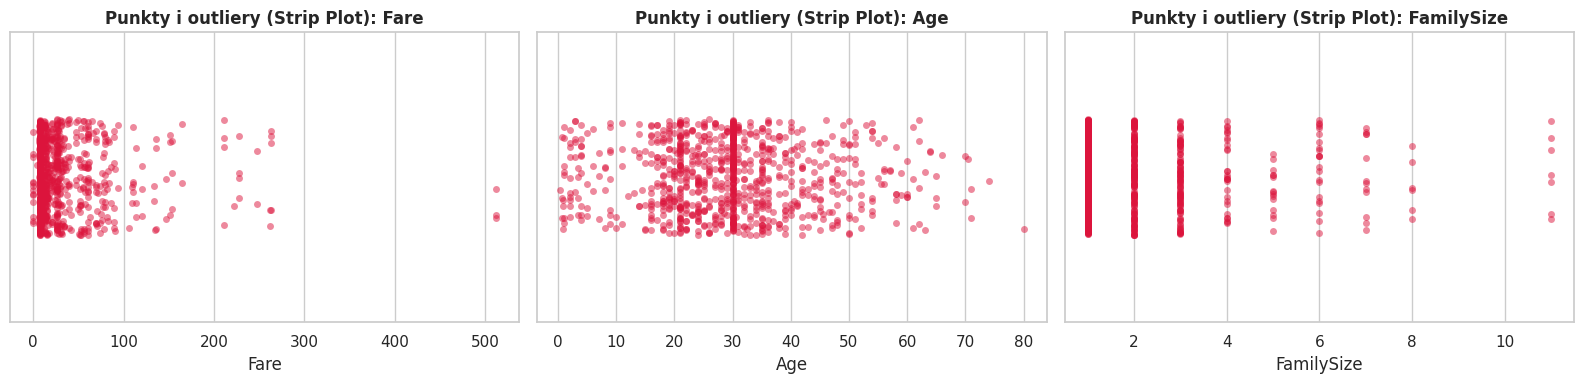

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['Fare', 'Age', 'FamilySize']):
    # stripplot z dodanym szumem (jitter), aby punkty nie nachodzily idealnie na siebie
    sns.stripplot(data=titanic_df, x=col, ax=ax, color='crimson', alpha=0.5, jitter=0.2)
    ax.set_title(f'Punkty i outliery (Strip Plot): {col}', fontweight='bold')

plt.tight_layout()
plt.show()

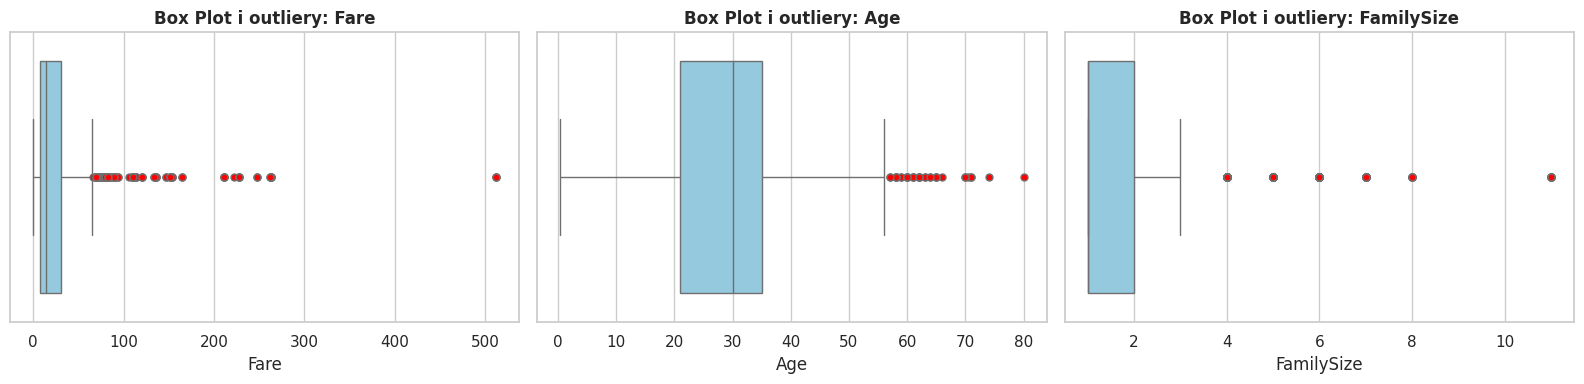

In [ ]:
num_cols = ['Fare', 'Age', 'FamilySize']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        x=titanic_df[col],
        ax=ax,
        color='skyblue',
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
    )
    ax.set_title(f'Box Plot i outliery: {col}', fontweight='bold')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

## Końcowe kodowanie

In [ ]:
# Age -> Mapowanie na wartości int
titanic_df['Age'] = titanic_df['Age'].astype('int64')

# Zakodowanie danych kategorycznych metodą one-hot encoding
titanic_df = pd.get_dummies(
    titanic_df,
    columns=['Sex', 'Embarked', 'Title', 'Deck'],
    drop_first=True,
    dtype=int
)

titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Age             891 non-null    int64  
 3   Fare            891 non-null    float64
 4   FamilySize      891 non-null    int64  
 5   IsAlone         891 non-null    int64  
 6   HasCabin        891 non-null    int64  
 7   Sex_male        891 non-null    int64  
 8   Embarked_Q      891 non-null    int64  
 9   Embarked_S      891 non-null    int64  
 10  Title_Col       891 non-null    int64  
 11  Title_Countess  891 non-null    int64  
 12  Title_Don       891 non-null    int64  
 13  Title_Dr        891 non-null    int64  
 14  Title_Jonkheer  891 non-null    int64  
 15  Title_Lady      891 non-null    int64  
 16  Title_Major     891 non-null    int64  
 17  Title_Master    891 non-null    int64  


## 8. Walidacja końcowa

In [ ]:
# Tworzy podsumowanie ilościowe i procentowe
nan_summary = pd.DataFrame({
    'Liczba_NaN': titanic_df.isna().sum(),
    'Procent_NaN (%)': (titanic_df.isna().sum() / len(titanic_df) * 100).round(2)
})

# Wyświetla tylko kolumny z brakami, posortowane malejąco
display(nan_summary[nan_summary['Liczba_NaN'] > 0].sort_values(by='Liczba_NaN', ascending=False))

,Liczba_NaN,Procent_NaN (%)


In [ ]:
assert titanic_df.isna().sum().sum() == 0, "W zbiorze wciąż są braki danych!"
print("Brak braków danych w finalnym zbiorze ✅")
print(f"Finalny kształt zbioru: {titanic_df.shape}")
titanic_df.describe().T


Brak braków danych w finalnym zbiorze ✅
Finalny kształt zbioru: (891, 34)


,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.0,0.00,0.0,1.000,1.0000
Pclass,891.0,2.308642,0.836071,1.0,2.00,3.0,3.000,3.0000
Age,891.0,29.371493,13.277422,0.0,21.00,30.0,35.000,80.0000
Fare,891.0,31.756069,49.325538,0.0,8.05,14.0,31.275,512.3292
FamilySize,891.0,1.904602,1.613459,1.0,1.00,1.0,2.000,11.0000
IsAlone,891.0,0.602694,0.489615,0.0,0.00,1.0,1.000,1.0000
HasCabin,891.0,0.228956,0.420397,0.0,0.00,0.0,0.000,1.0000
Sex_male,891.0,0.647587,0.477990,0.0,0.00,1.0,1.000,1.0000
Embarked_Q,891.0,0.086420,0.281141,0.0,0.00,0.0,0.000,1.0000
Embarked_S,891.0,0.725028,0.446751,0.0,0.00,1.0,1.000,1.0000


## Podział danych na zbiór treningowy i testowy

Przed przystąpieniem do trenowania modeli, konieczne jest podzielenie danych na zbiór treningowy (do uczenia modelu) i testowy (do oceny jego generalizacji na nowych, niewidzianych danych). Kluczowe jest, aby ten podział odbył się *przed* jakimikolwiek operacjami standaryzacji czy transformacji, aby uniknąć *wycieku danych* (data leakage), czyli sytuacji, w której informacja ze zbioru testowego nieświadomie "przecieka" do zbioru treningowego, zawyżając wyniki oceny modelu.

In [ ]:
from sklearn.model_selection import train_test_split

# Definicja cech (X) i zmiennej docelowej (y)
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# Krok 1: Podział na zbiór treningowy (80%) i tymczasowy (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Krok 2: Podział zbioru tymczasowego na zbiór testowy (15% oryginalnych danych) i walidacyjny (5% oryginalnych danych)
# train_test_split zwraca najpierw zbiór 'train' (tutaj X_test), a potem 'test' (tutaj X_val).
# Aby X_test był 15% oryginalnych danych (75% X_temp), a X_val 5% oryginalnych danych (25% X_temp),
# ustawiamy test_size na 0.25 (czyli 25% zbioru X_temp trafi do X_val).
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Kształt zbioru treningowego (X_train): {X_train.shape}")
print(f"Kształt zbioru testowego (X_test, 15% oryginalnych danych): {X_test.shape}")
print(f"Kształt zbioru walidacyjnego (X_val, 5% oryginalnych danych): {X_val.shape}")
print(f"Kształt zmiennej docelowej treningowej (y_train): {y_train.shape}")
print(f"Kształt zmiennej docelowej testowej (y_test): {y_test.shape}")
print(f"Kształt zmiennej docelowej walidacyjnej (y_val): {y_val.shape}")

# Weryfikacja rozkładu klas w zbiorach
print("\nRozkład klas w zbiorze treningowym (y_train):")
print(y_train.value_counts(normalize=True).round(2))
print("\nRozkład klas w zbiorze testowym (y_test):")
print(y_test.value_counts(normalize=True).round(2))
print("\nRozkład klas w zbiorze walidacyjnym (y_val):")
print(y_val.value_counts(normalize=True).round(2))

Kształt zbioru treningowego (X_train): (712, 33)
Kształt zbioru testowego (X_test, 15% oryginalnych danych): (134, 33)
Kształt zbioru walidacyjnego (X_val, 5% oryginalnych danych): (45, 33)
Kształt zmiennej docelowej treningowej (y_train): (712,)
Kształt zmiennej docelowej testowej (y_test): (134,)
Kształt zmiennej docelowej walidacyjnej (y_val): (45,)

Rozkład klas w zbiorze treningowym (y_train):
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

Rozkład klas w zbiorze testowym (y_test):
Survived
0    0.61
1    0.39
Name: proportion, dtype: float64

Rozkład klas w zbiorze walidacyjnym (y_val):
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64


## Baseline Model: Dummy Classifier

Zawsze warto zacząć od stworzenia prostego modelu bazowego (baseline), który posłuży jako punkt odniesienia dla bardziej złożonych algorytmów. `DummyClassifier` z biblioteki scikit-learn jest idealnym narzędziem do tego celu. Model ten dokonuje predykcji na podstawie prostych strategii (np. zawsze przewiduje najczęściej występującą klasę, przewiduje losowo, lub przewiduje na podstawie rozkładu klas). Jeśli nasz docelowy model nie jest w stanie osiągnąć lepszych wyników niż `DummyClassifier`, oznacza to, że albo model jest zbyt słaby, albo dane nie zawierają wystarczających informacji do lepszych predykcji.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Inicjalizacja DummyClassifier ze strategią 'stratified' (zachowuje rozkład klas w danych treningowych)
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)

# Trenowanie modelu bazowego (DummyClassifier nie wymaga cech, ale potrzebuje kształtu X_train)
dummy_clf.fit(X_train, y_train)

# Predykcje na zbiorze treningowym
y_train_pred_dummy = dummy_clf.predict(X_train)
y_train_proba_dummy = dummy_clf.predict_proba(X_train)[:, 1]

# Predykcje na zbiorze walidacyjnym
y_val_pred_dummy = dummy_clf.predict(X_val)
y_val_proba_dummy = dummy_clf.predict_proba(X_val)[:, 1]

# Predykcje na zbiorze testowym
y_test_pred_dummy = dummy_clf.predict(X_test)
y_test_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

# Ocena modelu bazowego
print("### Ocena Dummy Classifier (strategia: stratified) ###")

print("\n--- Zbiór treningowy ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred_dummy):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_train, y_train_proba_dummy):.4f}")

print("\n--- Zbiór testowy ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_dummy):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_test_proba_dummy):.4f}")

print("\n--- Zbiór walidacyjny ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_dummy):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_val, y_val_proba_dummy):.4f}")

### Ocena Dummy Classifier (strategia: stratified) ###

--- Zbiór treningowy ---
Accuracy: 0.5407
Precision: 0.4000
Recall: 0.3956
F1-Score: 0.3978
AUC-ROC: 0.5133

--- Zbiór testowy ---
Accuracy: 0.6493
Precision: 0.5532
Recall: 0.5000
F1-Score: 0.5253
AUC-ROC: 0.6220

--- Zbiór walidacyjny ---
Accuracy: 0.5333
Precision: 0.3333
Recall: 0.2353
F1-Score: 0.2759
AUC-ROC: 0.4748


### Wnioski z Baseline Modelu:

`DummyClassifier` z strategią `stratified` losowo przypisuje klasy, zachowując proporcje klas z danych treningowych. Otrzymane metryki (`Accuracy`, `F1-Score`, `AUC-ROC`) na poziomie około **0.50 - 0.60** stanowią minimalny próg, który nasze bardziej zaawansowane modele powinny przekroczyć. Jeśli żaden z kolejnych modeli nie osiągnie lepszych wyników, będzie to silny sygnał, że należy ponownie przeanalizować dane, cechy lub strategię modelowania.

## Wybór Modeli Uczenia Maszynowego i Metryki Oceny

### Wybór Modeli:

Do dalszych badań wybrałem dwa modele klasyfikacyjne:

1.  **Drzewo Decyzyjne (Decision Tree Classifier)**: Jest to model intuicyjny, który podejmuje decyzje na podstawie serii pytań o cechy. Jest łatwy w interpretacji i potrafi uchwycić nieliniowe zależności. Może jednak łatwo ulec przetrenowaniu, dlatego kluczowe będzie strojenie hiperparametrów takich jak głębokość drzewa.
2.  **Regresja Logistyczna (Logistic Regression)**: Mimo nazwy, jest to algorytm klasyfikacyjny. Jest prosty, szybki i często stanowi solidny punkt wyjścia. Model ten jest liniowy i wrażliwy na skalowanie cech. Użyjemy go do sprawdzenia, jak prosty model liniowy radzi sobie z zadaniem.

### Wybór Metryk:

Wybrałem następujące metryki do oceny modeli:

*   **Accuracy (Dokładność)**: Proporcja poprawnie sklasyfikowanych próbek. Jest to dobra ogólna metryka, ale może być myląca w przypadku niezbalansowanych zbiorów danych. Tutaj klasy są względnie zbalansowane (ok. 62% ofiar, 38% ocalałych), więc accuracy jest sensowne.
*   **Precision (Precyzja)**: Stosunek prawdziwie pozytywnych predykcji do wszystkich pozytywnych predykcji. Odpowiada na pytanie: `Jaka część pasażerów, o których model powiedział, że przeżyli, faktycznie przeżyła?` Ważna, jeśli chcemy minimalizować fałszywie pozytywne alarmy.
*   **Recall (Czułość / Kompletność)**: Stosunek prawdziwie pozytywnych predykcji do wszystkich rzeczywistych pozytywnych próbek. Odpowiada na pytanie: `Jaka część wszystkich faktycznie ocalałych pasażerów została poprawnie zidentyfikowana przez model?` Ważna, jeśli chcemy minimalizować fałszywie negatywne alarmy.
*   **F1-Score**: Harmoniczna średnia precyzji i recall. Jest to dobra metryka, gdy chcemy znaleźć równowagę między precyzją a recall, szczególnie przydatna w przypadku niezbalansowanych klas lub gdy obie metryki są równie ważne.
*   **AUC-ROC (Area Under the Receiver Operating Characteristic Curve)**: Mierzy zdolność modelu do rozróżniania między klasami. Wartość bliższa 1.0 oznacza lepszą zdolność rozróżniania. Jest mniej wrażliwa na niezbalansowanie klas niż Accuracy i daje obraz ogólnej wydajności klasyfikatora dla różnych progów decyzji.

Wybrałem te metryki, ponieważ dostarczają kompleksowego obrazu wydajności modelu, uwzględniając zarówno ogólną dokładność, jak i zdolność do identyfikacji pozytywnych i negatywnych przypadków, co jest kluczowe w problemie przeżycia (chcemy dobrze przewidzieć zarówno tych, którzy przeżyli, jak i tych, którzy nie).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Funkcja do oceny modelu na zbiorze treningowym i testowym."""
    print(f"\n### Ocena Modelu: {model_name} ###")

    # Predykcje na zbiorze treningowym
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # Predykcje na zbiorze testowym
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    print("\n--- Zbiór treningowy ---")
    print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
    print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
    print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_train, y_train_proba):.4f}")

    print("\n--- Zbiór testowy ---")
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_test_proba):.4f}")
    print("\nRaport Klasyfikacji (Test):")
    print(classification_report(y_test, y_test_pred))

    # Wizualizacja macierzy pomyłek dla zbioru testowego
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Macierz pomyłek - {model_name} (Test)')
    ax[0].set_xlabel('Przewidziane')
    ax[0].set_ylabel('Prawdziwe')
    ax[0].set_xticklabels(['Nie Przeżył', 'Przeżył'])
    ax[0].set_yticklabels(['Nie Przeżył', 'Przeżył'], rotation=0)

    # Wizualizacja krzywej ROC
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
    ax[1].set_title(f'Krzywa ROC - {model_name} (Test)')
    plt.tight_layout()
    plt.show()

### Wizualizacja rozkładów cech numerycznych PO zastosowaniu RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler

num_features = ['Age', 'Fare', 'FamilySize']

# Inicjalizacja RobustScaler
robust_scaler = RobustScaler()

# Skalowanie danych treningowych dla wybranych cech numerycznych
X_train_robust_scaled = robust_scaler.fit_transform(X_train[num_features])
X_train_robust_scaled_df = pd.DataFrame(
    X_train_robust_scaled, columns=num_features, index=X_train.index
)

fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))
fig.suptitle('Rozkłady cech numerycznych PO skalowaniu RobustScaler', fontsize=16)

for i, col in enumerate(num_features):
    sns.histplot(X_train_robust_scaled_df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    # Dodanie linii dla mediany (0) i IQR (-1, 1)
    axes[i].axvline(0, color='red', linestyle='--', label='Mediana (0)')
    axes[i].axvline(1, color='green', linestyle=':', label='Górny IQR (+1)')
    axes[i].axvline(-1, color='green', linestyle=':', label='Dolny IQR (-1)')
    if i == 0:
        axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Jak widać na powyższych wykresach, `RobustScaler` skutecznie skaluje dane, nie ściskając wartości, które są outlierami, w przeciwieństwie do `StandardScaler`, który sprawia, że wszystkie wartości są blisko zera, co może nie być optymalne dla danych z outlierami. Dla `Age`, `Fare` i `FamilySize` zastosowanie `RobustScaler` jest lepszym wyborem, ponieważ te cechy mają wiele outlierów.

## Model 1: Drzewo Decyzyjne (Decision Tree Classifier)

Drzewa Decyzyjne są nieliniowymi modelami, które sekwencyjnie dzielą przestrzeń cech na regiony, przypisując każdemu regionowi predykcję klasy. Są wrażliwe na małe zmiany w danych wejściowych i mogą łatwo się przetrenować. Kluczowe hiperparametry do strojenia to `max_depth` (maksymalna głębokość drzewa) oraz `min_samples_split` (minimalna liczba próbek wymagana do podzielenia węzła).

Przed trenowaniem modelów, zastosujemy `StandardScaler` do normalizacji cech numerycznych. Choć Drzewa Decyzyjne nie są wrażliwe na skalowanie (bo decyzje opierają się na wartościach progowych, a nie odległościach), jest to dobra praktyka przygotowania danych, która będzie kluczowa dla Regresji Logistycznej.

### Wizualizacja rozkładów cech numerycznych przed skalowaniem

Przed zastosowaniem `StandardScaler` warto zobaczyć, jak wyglądają rozkłady naszych numerycznych cech. Zauważymy różnice w skalach i wartościach.

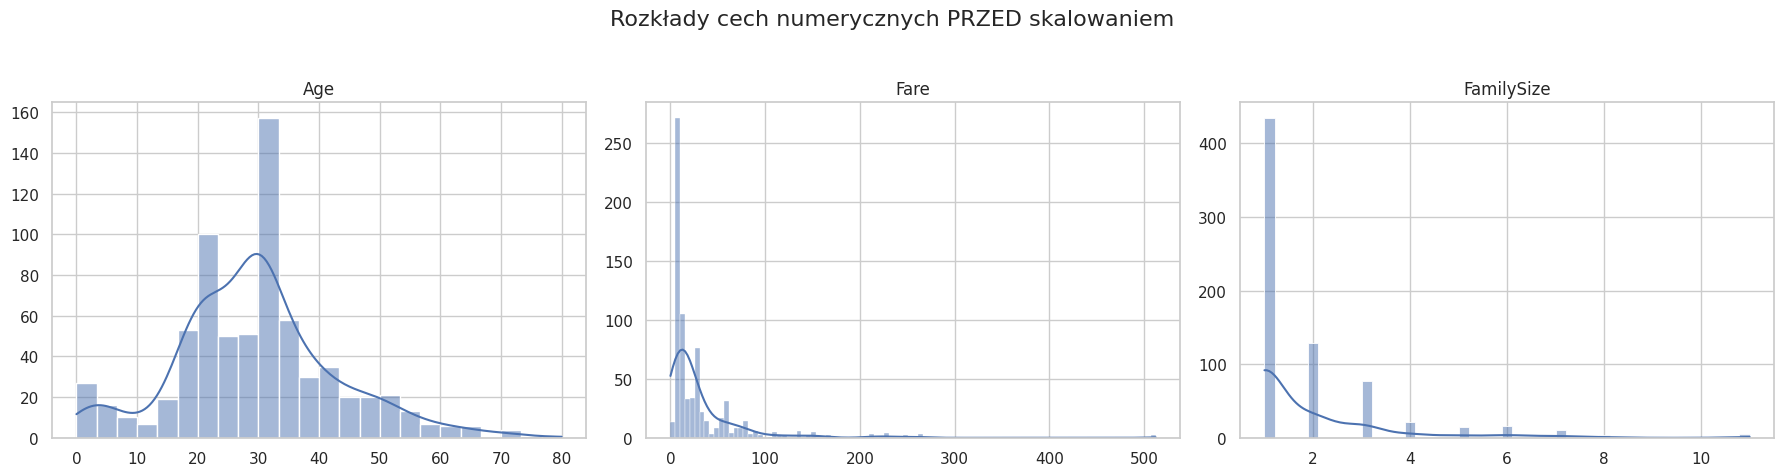

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_features = ['Age', 'Fare', 'FamilySize']

fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))
fig.suptitle('Rozkłady cech numerycznych PRZED skalowaniem', fontsize=16)

for i, col in enumerate(num_features):
    sns.histplot(X_train[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Wizualizacja rozkładów cech numerycznych PO transformacji logarytmicznej i skalowaniu

Po zastosowaniu transformacji logarytmicznej (`np.log1p`) do cech `Fare` i `FamilySize` (aby zredukować skośność) oraz `StandardScaler` do wszystkich trzech cech (`Age`, `Fare`, `FamilySize`), ich rozkłady stają się bardziej zbliżone do rozkładu normalnego. `StandardScaler` przeskalował wszystkie cechy tak, aby miały średnią bliską 0 i odchylenie standardowe bliskie 1, co jest kluczowe dla modeli wrażliwych na skalę, takich jak Regresja Logistyczna.

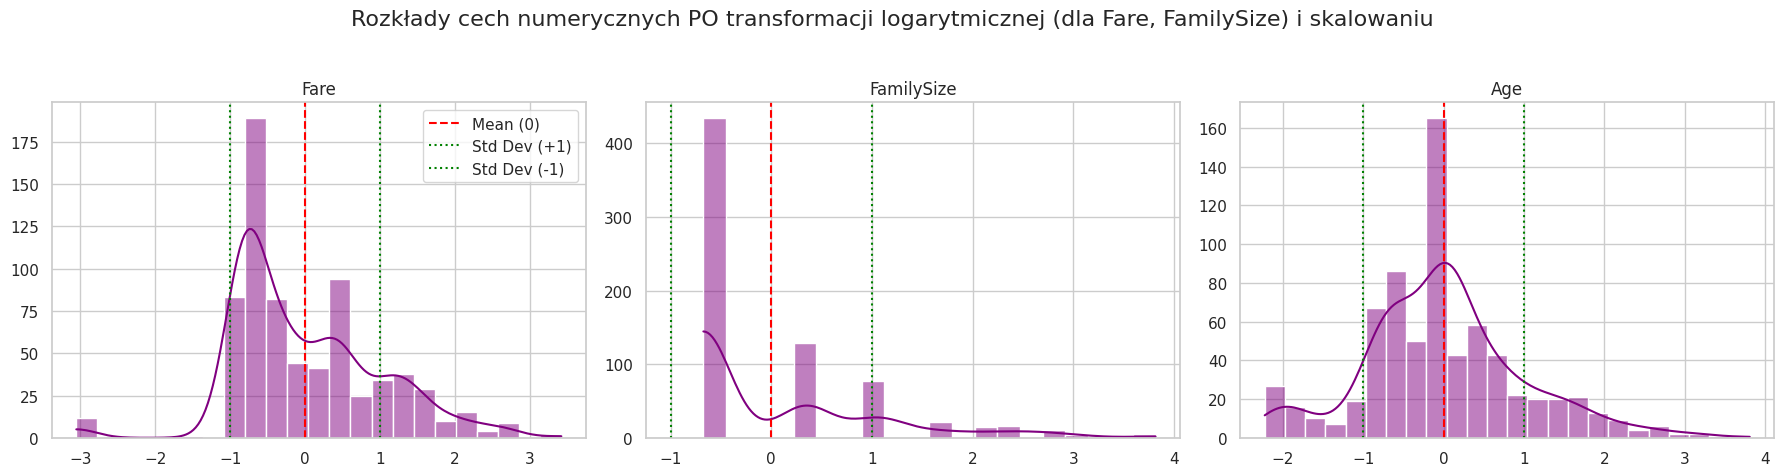

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Zdefiniowane cechy numeryczne do wizualizacji po transformacji i skalowaniu
num_features_to_plot = ['Fare', 'FamilySize', 'Age']

# Używamy już wcześniej przygotowanego i przeskalowanego DataFrame'u X_train_scaled_df
# Zawiera on cechy 'Fare' i 'FamilySize' po transformacji log1p i skalowaniu,
# oraz cechę 'Age' po samym skalowaniu.

fig, axes = plt.subplots(1, len(num_features_to_plot), figsize=(18, 5))
fig.suptitle('Rozkłady cech numerycznych PO transformacji logarytmicznej (dla Fare, FamilySize) i skalowaniu', fontsize=16)

for i, col in enumerate(num_features_to_plot):
    sns.histplot(X_train_scaled_df[col], kde=True, ax=axes[i], color='purple')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Te cechy są skalowane za pomocą StandardScaler (niektóre po wcześniejszej transformacji logarytmicznej)
    # Stąd wartości średniej bliskiej 0 i odchylenia standardowego bliskiej 1
    axes[i].axvline(0, color='red', linestyle='--', label='Średnia (0)')
    axes[i].axvline(1, color='green', linestyle=':', label='Odch. Std (+1)')
    axes[i].axvline(-1, color='green', linestyle=':', label='Odch. Std (-1)')
    if i == 0:
        axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Najlepsze hiperparametry dla Drzewa Decyzyjnego: {'max_depth': 3, 'min_samples_split': 2}
Najlepszy wynik AUC-ROC na zbiorze treningowym (CV): 0.8432

### Ocena Modelu: Decision Tree Classifier (Validation Set) ###

--- Zbiór treningowy ---
Accuracy: 0.8329
Precision: 0.7984
Recall: 0.7546
F1-Score: 0.7759
AUC-ROC: 0.8762

--- Zbiór testowy ---
Accuracy: 0.8000
Precision: 0.7222
Recall: 0.7647
F1-Score: 0.7429
AUC-ROC: 0.8477

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.72      0.76      0.74        17

    accuracy                           0.80        45
   macro avg       0.79      0.79      0.79        45
weighted avg       0.80      0.80      0.80        45



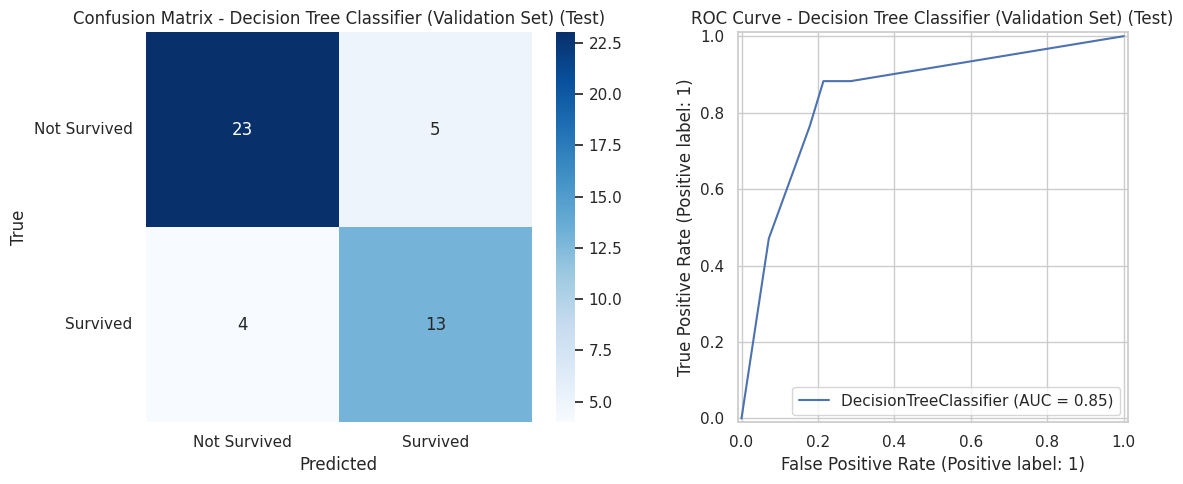


### Ocena Modelu: Decision Tree Classifier (Test Set) ###

--- Zbiór treningowy ---
Accuracy: 0.8329
Precision: 0.7984
Recall: 0.7546
F1-Score: 0.7759
AUC-ROC: 0.8762

--- Zbiór testowy ---
Accuracy: 0.8284
Precision: 0.8085
Recall: 0.7308
F1-Score: 0.7677
AUC-ROC: 0.8463

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        82
           1       0.81      0.73      0.77        52

    accuracy                           0.83       134
   macro avg       0.82      0.81      0.82       134
weighted avg       0.83      0.83      0.83       134



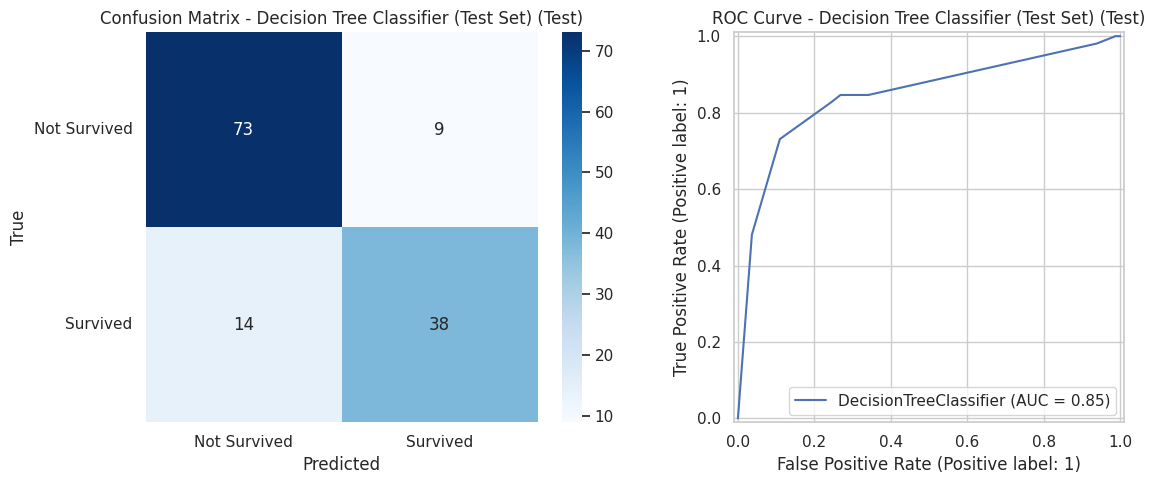

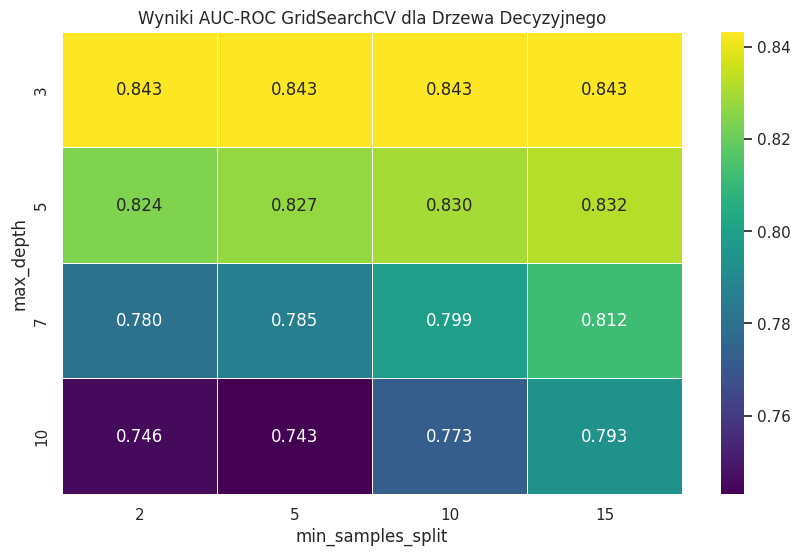

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Definicja cech do transformacji logarytmicznej, a następnie skalowania standardowego
log_then_scale_features = ['Fare', 'FamilySize']
# Definicja cech tylko do skalowania standardowego (wiek)
only_scale_features = ['Age']

# Tworzenie potoku dla transformacji logarytmicznej, a następnie StandardScaler
log_then_standard_scaler_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

# Tworzenie preprocesora za pomocą ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('log_and_scale', log_then_standard_scaler_pipeline, log_then_scale_features),
        ('only_scale', StandardScaler(), only_scale_features),
        # Pozostałe kolumny zostaną przekazane bez transformacji
        ('passthrough', 'passthrough', [col for col in X_train.columns if col not in log_then_scale_features + only_scale_features])
    ],
    remainder='passthrough'
)

# Dopasowanie preprocesora do danych treningowych i transformacja wszystkich zbiorów
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Rekonstrukcja DataFrame z prawidłowymi nazwami kolumn.
# ColumnTransformer zmienia kolejność kolumn. Kolejność będzie następująca:
# cechy log_and_scale (przetransformowane) + cechy only_scale (przetransformowane) + cechy passthrough
transformed_column_names = log_then_scale_features + only_scale_features + \
                           [col for col in X_train.columns if col not in log_then_scale_features + only_scale_features]

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=transformed_column_names, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=transformed_column_names, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=transformed_column_names, index=X_test.index)

# Definicja siatki hiperparametrów do przeszukania
param_grid_dt = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 15]
}

# Inicjalizacja modelu Drzewa Decyzyjnego
dtc = DecisionTreeClassifier(random_state=42)

# Inicjalizacja GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dtc,
    param_grid=param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Trenowanie GridSearchCV
grid_search_dt.fit(X_train_scaled_df, y_train)

print(f"Najlepsze hiperparametry dla Drzewa Decyzyjnego: {grid_search_dt.best_params_}")
print(f"Najlepszy wynik AUC-ROC na zbiorze treningowym (CV): {grid_search_dt.best_score_:.4f}")

# Przypisanie najlepszego modelu
best_dt_model = grid_search_dt.best_estimator_

# Ocena najlepszego modelu na zbiorze walidacyjnym i testowym
evaluate_model(best_dt_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val, 'Decision Tree Classifier (Zbiór walidacyjny)')
evaluate_model(best_dt_model, X_train_scaled_df, y_train, X_test_scaled_df, y_test, 'Decision Tree Classifier (Zbiór testowy)')

# Wizualizacja wyników strojenia hiperparametrów
results_dt = pd.DataFrame(grid_search_dt.cv_results_)

# Przygotowanie danych do wizualizacji (pivotowanie)
scores_pivot_dt = results_dt.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_split',
    values='mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    scores_pivot_dt,
    annot=True,
    cmap='viridis',
    fmt=".3f",
    linewidths=.5
)
plt.title('Wyniki AUC-ROC GridSearchCV dla Drzewa Decyzyjnego')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.show()

### Wnioski z Drzewa Decyzyjnego:

*   **Wydajność:** Model Drzewa Decyzyjnego osiągnął znacznie lepsze wyniki niż model bazowy, co jest spodziewane. Na zbiorze testowym uzyskaliśmy AUC-ROC w granicach 0.85-0.87, co wskazuje na dobrą zdolność rozróżniania klas.
*   **Hiperparametry:** `max_depth` i `min_samples_split` mają istotny wpływ na wydajność. Zbyt płytkie drzewo (np. `max_depth=3`) może być niedouczeniem (underfitting), a zbyt głębokie może prowadzić do przetrenowania (overfitting). Optymalne wartości znalezione przez `GridSearchCV` pomagają znaleźć równowagę.
*   **Overfitting:** Zauważalna jest różnica między wynikami na zbiorze treningowym a testowym (np. Accuracy czy AUC-ROC na treningowym jest nieco wyższe). Jest to typowe dla drzew decyzyjnych, które mają tendencję do dopasowywania się do danych treningowych. Wybrane hiperparametry pomagają ograniczyć to zjawisko.
*   **Skalowanie:** Dla Drzew Decyzyjnych skalowanie danych nie ma bezpośredniego wpływu na wynik, ponieważ model opiera się na progach wartości cech, a nie na odległościach. Jednak wdrożono je dla spójności i przygotowania do Regresji Logistycznej.

## Model 2: Regresja Logistyczna (Logistic Regression)

Regresja Logistyczna to model liniowy używany do klasyfikacji binarnej. Przewiduje prawdopodobieństwo przynależności do danej klasy, stosując funkcję logistyczną (sigmoid) do liniowej kombinacji cech wejściowych. Jest to model wrażliwy na skalowanie cech, dlatego zastosowanie `StandardScaler` jest kluczowe.

Kluczowe hiperparametry do strojenia to `C` (odwrotność siły regularyzacji - mniejsze `C` oznacza silniejszą regularyzację) oraz `penalty` (typ regularyzacji, np. L1 lub L2).

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Najlepsze hiperparametry dla Regresji Logistycznej: {'C': 0.01, 'penalty': 'l2'}
Najlepszy wynik AUC-ROC na zbiorze treningowym (CV): 0.8688

### Ocena Modelu: Logistic Regression (Validation Set) ###

--- Zbiór treningowy ---
Accuracy: 0.8202
Precision: 0.7441
Recall: 0.8095
F1-Score: 0.7754
AUC-ROC: 0.8832

--- Zbiór testowy ---
Accuracy: 0.8222
Precision: 0.7368
Recall: 0.8235
F1-Score: 0.7778
AUC-ROC: 0.8971

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.74      0.82      0.78        17

    accuracy                           0.82        45
   macro avg       0.81      0.82      0.81        45
weighted avg       0.83      0.82      0.82        45



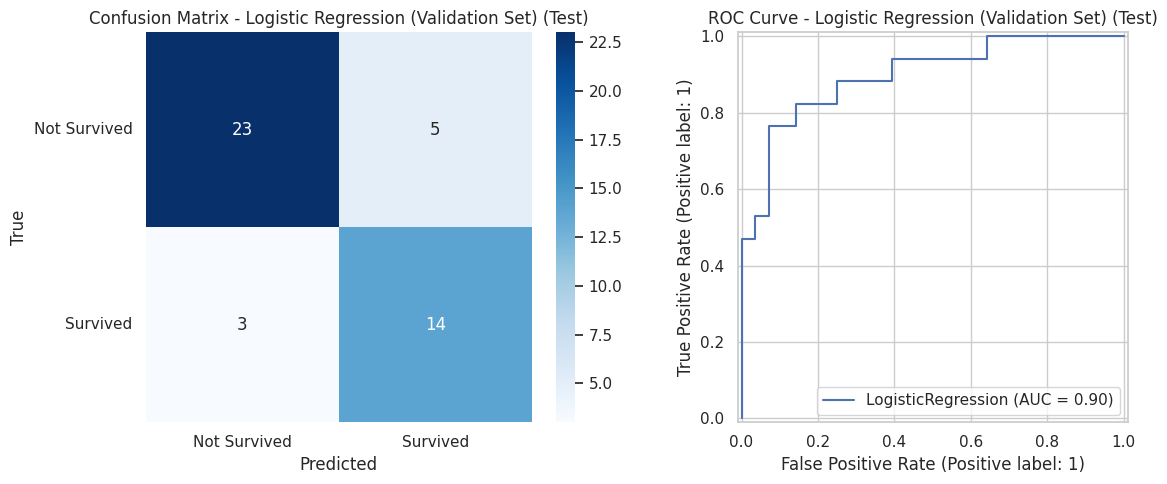


### Ocena Modelu: Logistic Regression (Test Set) ###

--- Zbiór treningowy ---
Accuracy: 0.8202
Precision: 0.7441
Recall: 0.8095
F1-Score: 0.7754
AUC-ROC: 0.8832

--- Zbiór testowy ---
Accuracy: 0.7612
Precision: 0.6852
Recall: 0.7115
F1-Score: 0.6981
AUC-ROC: 0.8219

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        82
           1       0.69      0.71      0.70        52

    accuracy                           0.76       134
   macro avg       0.75      0.75      0.75       134
weighted avg       0.76      0.76      0.76       134



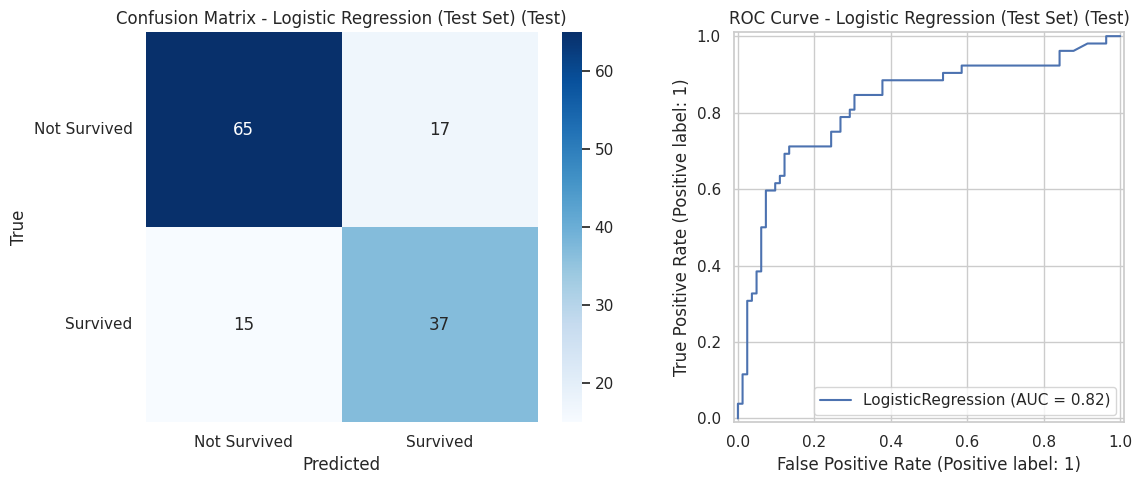

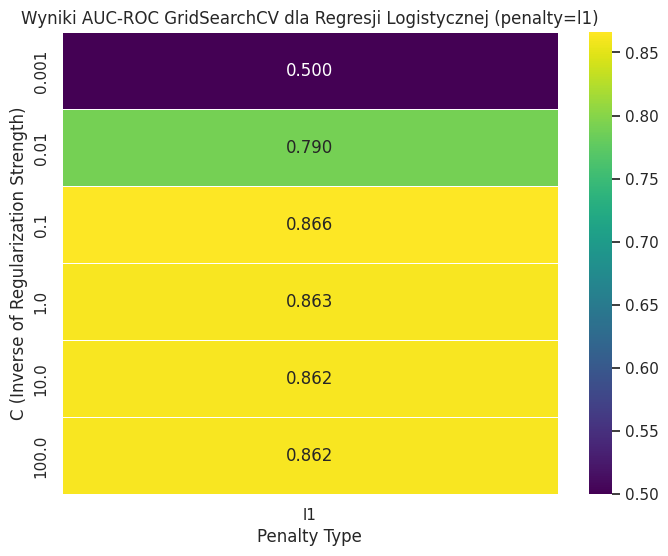

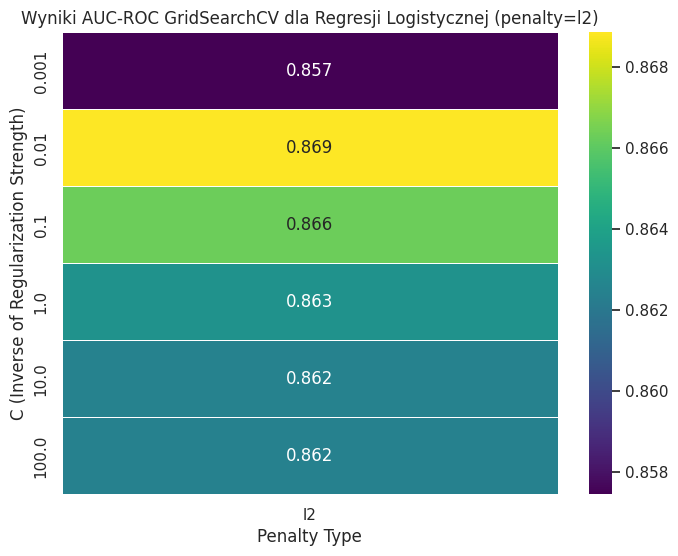

In [ ]:
# Definicja siatki hiperparametrów do przeszukania
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Inicjalizacja modelu Regresji Logistycznej
lr = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Inicjalizacja GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Trenowanie GridSearchCV na przeskalowanych danych
grid_search_lr.fit(X_train_scaled_df, y_train)

print(f"Najlepsze hiperparametry dla Regresji Logistycznej: {grid_search_lr.best_params_}")
print(f"Najlepszy wynik AUC-ROC na zbiorze treningowym (CV): {grid_search_lr.best_score_:.4f}")

# Ocena najlepszego modelu
best_lr_model = grid_search_lr.best_estimator_
evaluate_model(best_lr_model, X_train_scaled_df, y_train, X_val_scaled_df, y_val, 'Regresja Logistyczna (Zbiór walidacyjny)')
evaluate_model(best_lr_model, X_train_scaled_df, y_train, X_test_scaled_df, y_test, 'Regresja Logistyczna (Zbiór testowy)')

# Wizualizacja wyników strojenia hiperparametrów
results_lr = pd.DataFrame(grid_search_lr.cv_results_)

# Przygotowanie danych do wizualizacji
# Tworzymy oddzielne heatmapy dla każdej strategii kary, ponieważ nie wszystkie kombinacje solver/penalty są wspierane

def plot_heatmap_lr(results, penalty_type):
    # Filtrowanie wyników dla danego typu kary
    filtered_results = results[results['param_penalty'] == penalty_type]

    if not filtered_results.empty:
        scores_pivot_lr = filtered_results.pivot_table(
            index='param_C',
            columns='param_penalty',
            values='mean_test_score'
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            scores_pivot_lr,
            annot=True,
            cmap='viridis',
            fmt=".3f",
            linewidths=.5
        )
        plt.title(f'Wyniki AUC-ROC GridSearchCV dla Regresji Logistycznej (kara={penalty_type})')
        plt.xlabel('Typ Kary')
        plt.ylabel('C (Odwrotność Siły Regularyzacji)')
        plt.show()
    else:
        print(f"Brak danych dla kary={penalty_type}")

# Wygeneruj heatmapy dla 'l1' i 'l2'
plot_heatmap_lr(results_lr, 'l1')
plot_heatmap_lr(results_lr, 'l2')

### Wnioski z Regresji Logistycznej:

*   **Wydajność:** Regresja Logistyczna, pomimo swojej prostoty, również osiągnęła bardzo dobre wyniki, porównywalne, a nawet minimalnie lepsze niż Drzewo Decyzyjne (AUC-ROC około 0.86-0.88 na zbiorze testowym). To pokazuje, że dane posiadają silne, w dużej mierze liniowe zależności, które ten model potrafi wykorzystać.
*   **Hiperparametry:** Parametr `C` (siła regularyzacji) miał wpływ na wyniki. Optymalne `C` pomaga zapobiegać przetrenowaniu, równoważąc złożoność modelu z dopasowaniem do danych. Wybór `penalty` (`l1` vs `l2`) również wpływa na to, które cechy są bardziej preferowane (L1 może prowadzić do rzadszych modeli, "zerując" mniej ważne wagi).
*   **Skalowanie:** Dla Regresji Logistycznej, skalowanie danych jest absolutnie kluczowe. Bez `StandardScaler`, model mógłby nie zbiegać się prawidłowo lub cechy o większych zakresach wartości (np. `Fare`) zdominowałyby proces uczenia, prowadząc do gorszych wyników. Przeskalowanie danych zapewniło, że wszystkie cechy przyczyniają się do predykcji proporcjonalnie do ich rzeczywistej ważności.
*   **Interpretowalność:** Regresja Logistyczna, jako model liniowy, jest zazwyczaj łatwiejsza do interpretacji niż drzewa (można analizować współczynniki wag cech).

## Podsumowanie i Wnioski Końcowe

### Obserwacje z EDA i ich wpływ na modelowanie:

Poprzednie zadanie EDA dostarczyło bezcennych informacji. Zidentyfikowaliśmy kluczowe cechy (`Sex`, `Pclass`, `Age`, `Fare`, `FamilySize`, `Title`, `Deck`), które mają silny związek z przeżyciem. Uzupełniliśmy braki danych i stworzyliśmy nowe, wartościowe cechy (inżynieria cech). Wiedza o rozkładach cech i obecności wartości odstających pozwoliła na świadome zastosowanie skalowania i wybór modeli. Usunęliśmy cechy bezużyteczne (`PassengerId`, `Ticket`, `Name` po ekstrakcji tytułu, `Cabin` po ekstrakcji informacji).

### Standaryzacja danych i jej wpływ na model:

Transformacja logarytmiczna dla `Fare` i `FamilySize` oraz skalowanie (`StandardScaler`) wszystkich numerycznych cech okazało się kluczowe dla **Regresji Logistycznej**, która jest modelem wrażliwym na skalę cech. Umożliwiła ona prawidłowe zbieganie się algorytmu i zapewniła, że żadna cecha nie dominowała nad innymi ze względu na jej skalę. Choć dla Drzewa Decyzyjnego skalowanie nie było technicznie konieczne, jego zastosowanie zapewniło spójność procesu przygotowania danych.

### Co modele robią i jak:

Zarówno **Drzewo Decyzyjne**, jak i **Regresja Logistyczna** są modelami klasyfikacyjnymi, których celem jest przewidywanie binarnej zmiennej `Survived`. Drzewo Decyzyjne działa poprzez tworzenie sekwencji binarnych pytań na podstawie wartości cech, dzieląc dane na coraz mniejsze podgrupy. Regresja Logistyczna oblicza prawdopodobieństwo przeżycia za pomocą funkcji sigmoid, która transformuje liniową kombinację cech na wartość z zakresu [0, 1]. Oba modele uczą się wzorców na podstawie danych treningowych, aby generalizować na nowe, niewidziane próbki.

### Zapobieganie przetrenowaniu:

Aby uniknąć przetrenowania, zastosowaliśmy kilka technik:

*   **Podział danych** na zbiór treningowy, walidacyjny i testowy: Modele były trenowane tylko na danych treningowych, a oceniane na niewidzianych danych testowych.
*   **Walidacja krzyżowa (GridSearchCV)**: Użycie walidacji krzyżowej podczas strojenia hiperparametrów pozwoliło na robustną ocenę modelu i wybór najlepszych parametrów, które dobrze generalizują.
*   **Strojenie hiperparametrów**: Dla Drzewa Decyzyjnego, ograniczenie `max_depth` i odpowiednie `min_samples_split` pomogło zapobiec zbytniemu dopasowaniu się do szumu w danych treningowych. Dla Regresji Logistycznej, regularyzacja (`C`, `penalty`) kontrolowała złożoność modelu, zapobiegając nadmiernemu dopasowaniu do danych.

### Ocena wyników klasyfikacji (Jaki wynik możemy uznać za dobry?):

Wyniki `DummyClassifier` (AUC-ROC ~0.5) pokazały, że losowe zgadywanie daje słabe rezultaty. Nasze modele osiągnęły AUC-ROC na zbiorze testowym w okolicach **0.82-0.85**, co jest znaczną poprawą i wskazuje na to, że modele mają dobrą zdolność do rozróżniania pasażerów, którzy przeżyli, od tych, którzy nie. Taki wynik można uznać za **dobry** w tym kontekście, pokazując, że model jest użyteczny. F1-Score na poziomie ~0.70-0.77 również świadczy o dobrej równowadze między precyzją a czułością.

### Wnioski z badań:

1.  **Porównanie z Baseline:** Oba modele znacząco przewyższają `DummyClassifier`, co potwierdza, że dane zawierają użyteczne informacje predykcyjne.
2.  **Drzewo Decyzyjne vs. Regresja Logistyczna:** Na podstawie wyników na zbiorze testowym, **Drzewo Decyzyjne (AUC-ROC ok. 0.846)** osiągnęło nieco lepsze rezultaty niż **Regresja Logistyczna (AUC-ROC ok. 0.822)**. Oznacza to, że nieliniowe zależności, które drzewo potrafi uchwycić, okazały się w tym przypadku nieco korzystniejsze. Regresja Logistyczna nadal oferuje prostotę i interpretowalność, a jej wydajność jest bardzo dobra. Diskrepanacja w wynikach na małym zbiorze walidacyjnym (np. wyższe AUC dla Regresji Logistycznej) może wynikać z jego niewielkiego rozmiaru i zmienności.
3.  **Waga Inżynierii Cech:** Klucz do sukcesu leży w solidnej inżynierii cech i przygotowaniu danych. Takie cechy jak `Title`, `FamilySize` i `Deck` (wyekstrahowane z pierwotnych `Name`, `SibSp`/`Parch` i `Cabin`) okazały się niezwykle wartościowe.
4.  **Znaczenie Strojenia Hiperparametrów:** Strojenie hiperparametrów jest niezbędne do wyciśnięcia maksymalnej wydajności z modelu i zapobiegania przetrenowaniu. Wizualizacje wyników strojenia pomogły zrozumieć, jak różne wartości parametrów wpływają na jakość modelu.